In [ ]:
#
# Copyright IBM Corp. 2025, 2026
# SPDX-License-Identifier: Apache-2.0
#
# Auxiliary functions to compute bit streams for parallel weight update schemes as a result of x and δ vectors


# Fully Parallel Outer Product in a ReRAM Crosspoint Array for Analog In-Memory Training: an ngspice Implementation with IBM Analog Filamentary Conductive-Metal-Oxide/HfOx ReRAM Device

Victoria Clerico<sup>1</sup>, Matteo Galetta<sup>1</sup>, Matias Senger<sup>1</sup>,Matias Senger<sup>1</sup>, Bert J. Offrein<sup>1</sup>, Valeria Bragaglia<sup>1</sup>

<sup>1</sup>Quantum and AI Systems, IBM Research Europe-Zurich,
Säumerstrasse 4, Rüschlikon, 8803, Zurich, Switzerland.

#### Description

This SPICE-python engine implements a fully parallel outer product operation using a 10x10 crosspoint array ngspice netlist. Each crosspoint cell is in a 1Transistor-1ReRAM configuration. The netlist includes the nFET model and the ngspice implementation of the IBM analog filamentary CMO/HfOx ReRAM device. The ngspice ReRAM model can be found in the sub-folder "simulation_models".

This notebook includes the codes needed to reproduce the results reported in [1].

[1] V. Clerico, M. Galetta, M. Senger, W. Choi, D.F. Falcone, A. Todri-Sanial, B.J. Offrein, and V. Bragaglia.
	“Proving Analog In-Memory Training with Fully Parallel Outer Product in ReRAM Crosspoint Array”
	Under review at npj Unconventional Computing (2026)

In [1]:
# Imports (libraries and local modules)
import numpy
from pathlib import Path
import pandas
import seaborn as sns
import numpy as np
import warnings
import os
import torch
import subprocess
import matplotlib.pyplot as plt
from src.spice_data_analyzer import SimulationDataAnalyzer
from src.utils.plotting import plot_conductance_map
from src.pulse_generator import ReRAMMatrixPulseGenerator
from src.weight_update import BitstreamGenerator
numpy.random.seed(0)
import yaml

In [2]:
# Load ReRAM device switching parameters, waveforms (voltage-time) parameters, and ngspice netlist 
# of a crosspoint array with n-type transistors and analog ReRAM devices
with open("simulation_parameters.yaml", 'r') as f:
	data = yaml.load(f, Loader=yaml.SafeLoader)
data = {k: float(v) for k, v in data.items()}
ARRAY_SIZE = 10		# Do not change unless new ngspice netlist is available
PATH_TO_WAVEFORMS_FOLDER = Path('waveforms')
crosspoint_array_file = Path("src/circuit/10x10.cir")


### Select weight update scheme that generates the pulse waveforms used for in-memory outer product

Two alternative update schemes are described in literature ([1] and [2]). In [2], the original proposed version, referred to here as the "Conventional stochastic parallel weight update scheme". In [1], a modification of this scheme is introduced, referred to as the "Gate-coincidence stochastic parallel weight update scheme" which uses a stochastic coincidence between the transistor's gate and one ReRAM terminal to mitigate IR drop during array updates. Read [1] for details.

[1] V. Clerico, M. Galetta, M. Senger, W. Choi, D.F. Falcone, A. Todri-Sanial, B.J. Offrein, and V. Bragaglia.
	“Proving Analog In-Memory Training with Fully Parallel Outer Product in ReRAM Crosspoint Array”
	Under review at npj Unconventional Computing (2026)

[2] T. Gokmen, and Y. Vlasov.
	“Acceleration of Deep Neural Network Training with Resistive Cross-Point Devices: Design Considerations”
	Frontiers in Neuroscience, v.10 p.333 (2016). https://doi.org/10.3389/fnins.2016.00333

In [3]:
# Set "conventional_scheme = False" to select the Gate-coincidence stochastic parallel weight update scheme, 
# otherwise "conventional_scheme = True" for Conventional stochastic parallel weight update scheme
conventional_scheme = False
if conventional_scheme:
    pulse_generator = ReRAMMatrixPulseGenerator(n_rows = ARRAY_SIZE,n_cols = ARRAY_SIZE, t_rise = data["T_RISE"],
                                            t_write = data["T_WRITE"], t_read = data["T_READ"],
                                            t_rise_gate= data["T_RISE_GATE"], t_wait= data["T_WAIT"],
                                            V_gates_pot = data["V_GATE_SET"], V_gates_dep = data["V_GATE_RESET"],
                                            V_row_pot = data["V_SET"],  V_col_pot = 0, V_standby_pot = data["V_SET"]/2, 
                                            V_row_dep = 0,  V_col_dep = data["V_RESET"], V_standby_dep = data["V_SET"]/2,
                                            V_row_read = data["V_READ"], V_col_read = 0)
else:
    pulse_generator = ReRAMMatrixPulseGenerator( n_rows = ARRAY_SIZE, n_cols = ARRAY_SIZE, t_rise = data["T_RISE"],
                                            t_write = data["T_WRITE"], t_read = data["T_READ"],
                                            t_rise_gate= data["T_RISE_GATE"], t_wait= data["T_WAIT"],
                                            V_gates_pot = data["V_GATE_SET"], V_gates_dep = data["V_GATE_RESET"],
                                            V_row_pot = data["V_SET"],  V_col_pot = 0, V_standby_pot = data["V_SET"], 
                                            V_row_dep = 0,  V_col_dep = data["V_RESET"], V_standby_dep = 0,
                                            V_row_read = data["V_READ"], V_col_read = 0, Gate_Coincidence=True)

# Waveforms are generated as .txt files appending sequential pulses. Each waveform is the input file for arbitrary voltage source circuits.
# For the netlist "./src/circuit/10x10.cir" row refer to bitlines, column to sourcelines and getes to wordlines (for waveform files & circuit layout correspondence).
pulse_generator.pulse_creator()
pulse_generator.set_waveform_folder(PATH_TO_WAVEFORMS_FOLDER)


#### First READ operation applied to the crosspoint array in SPICE and fetch conductance map

In [4]:
# Run ngspice with crosspoint array netlist as input
ngspice_command = f"ngspice --batch --output=ngspice_simulation.log {crosspoint_array_file}"
from src.utils.ngspice_file_parser import run_ngspice, initialize_cir_file_and_read, update_transient_time
initialize_cir_file_and_read(crosspoint_array_file, ngspice_command, pulse_generator=pulse_generator)

Starting SPICE simulation...
SPICE simulation finished successfully.


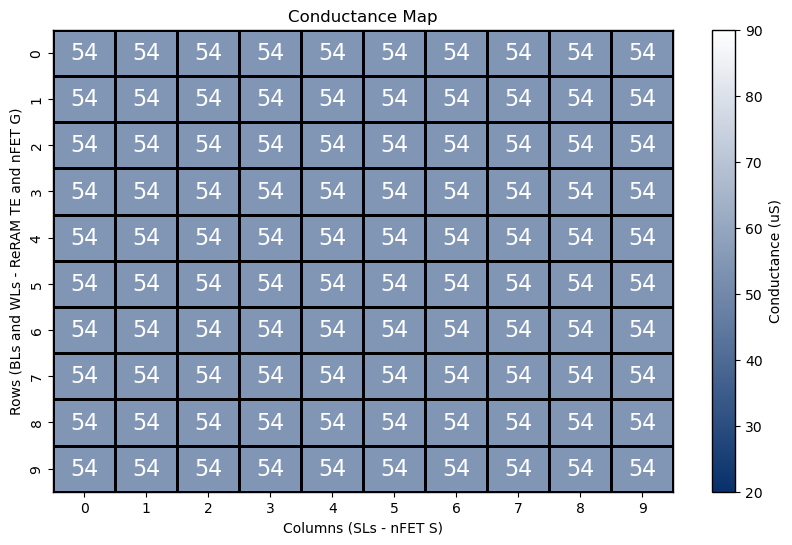

In [5]:
analyzer = SimulationDataAnalyzer(
    path_to_simulation_data = 'simulation_output/data.csv',
    t_read= data["T_READ"]
)
conductance_map = analyzer.generate_matrix_data()
plot_conductance_map(conductance_map, size=10)

#### In-memory parallel outer product - Waveform generation

For in-memory outer product, vectors x (∈ {0, +1}) and δ (∈ {−1, +1}, determining whether the update cycle applies SET or RESET operations) are encoded as probabilities [1],[2]. A bit stream is then generated, where each pulse slot includes either an up/down pulse or a stand-by voltage, chosen according to the probability derived from the x and δ vectors. The bit stream length (maximum number of pulses) is set in the simulation parameters file. For example, a bit stream of length 10 with an encoded probability of 0.5 will contain 5 pulses placed at random pulse slots in the waveform and 5 stand-by voltages.

In [6]:
# Recall bit stream generator (see "./src/weight_update.py" for details)
str = BitstreamGenerator(bit_length=data["BITSTREAM_LENGTH"])

# Define input and output vectors
row_vector = numpy.random.uniform(0, 1, size=10)
col_vector = numpy.random.uniform(-1, 1, size=10)
print("x_i =", row_vector,"\n\n& \n\nerr_j =",col_vector)
# Encode input and error vectors in probabilities and generate bit streams
row_bitstreams, col_bitstreams = str.get_bistreams(x=row_vector, err=col_vector)
# Waveforms are generated as .txt files appending sequential pulses. Each waveform is the input file for arbitrary voltage source circuits.
pulse_generator.reset_voltages()
pulse_generator.gen_stochastic_waveforms(x_bitstreams=row_bitstreams, err_bitstreams=col_bitstreams)
# SPICE transient
update_transient_time(crosspoint_array_file, time=pulse_generator._rows[-1].points[-3][0])

x_i = [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773   0.96366276 0.38344152] 

& 

err_j = [ 0.58345008  0.05778984  0.13608912  0.85119328 -0.85792788 -0.8257414
 -0.95956321  0.66523969  0.5563135   0.7400243 ]


#### Examples of waveforms (fixed, not updated with selected pulse schemes/simulation parameters) 

A programming pulse belonging to the waveform induces a change in the analog ReRAM conductance state (update) only when the area under the net voltage waveform is shaded dark gray (4 figures below). In the gate-coincidence stochastic parallel weight update scheme, a cell updates only when the full programming voltage (SET or RESET) is applied across the bitline and sourceline and a positive gate voltage is simultaneously applied through the wordline. In the conventional stochastic parallel weight update scheme, a cell updates whenever the full programming voltage (SET or RESET) is applied across the bitline and sourceline alone, since the wordlines remain enabled throughout the entire update cycle.

a. Gate-coincidence stochastic parallel weight update scheme - Update cycle with SET operations: (x,δ)=(+,+)

<img src="./figures/Gate_++.png" width="650">

b. Gate-coincidence stochastic parallel weight update scheme - Update cycle with RESET operations: (x,δ)=(+,-)

<img src="./figures/Gate_+-.png" width="650">

c. Conventional stochastic parallel weight update scheme - Update cycle with SET operations: (x,δ)=(+,+)

<img src="./figures/Conv_++.png" width="650">

c. Conventional stochastic parallel weight update scheme - Update cycle with RESET operations: (x,δ)=(+,-)

<img src="./figures/Conv_+-.png" width="650">


#### Run SPICE for parallel weight updates

In [7]:
# Run ngspice with crosspoint array netlist as input
run_ngspice(ngspice_command=ngspice_command)

Starting SPICE simulation...
SPICE simulation finished successfully.


#### Plot updated conductance map

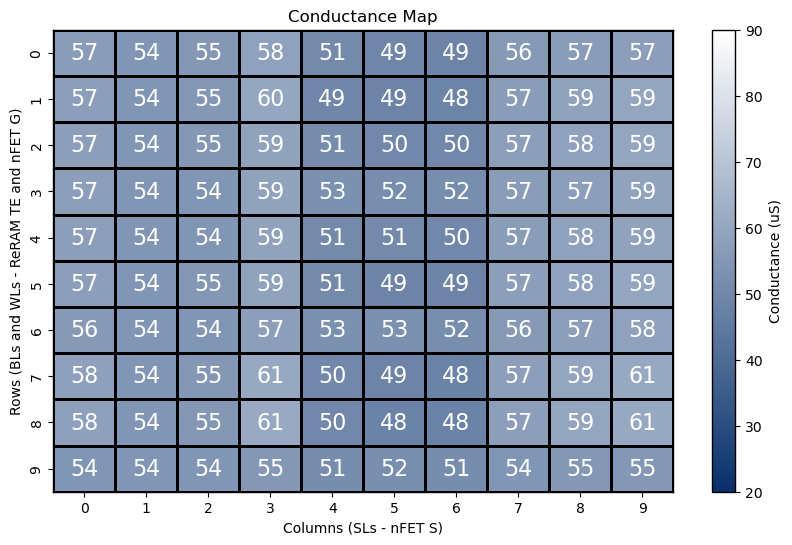

In [8]:
# Plot conductance map
updated_conductance_map = analyzer.generate_matrix_data()
plot_conductance_map(updated_conductance_map, size=10)

#### End of the fully parallel outer product in a ReRAM Crosspoint Array example

If another weight update phase is appended (input/error vectors generation, probabilities encoding, waveform creation, ngspice run), the crosspoint array will automatically use the last conductance state map as initial condition. The engine can be concatenated with forward/backward pass and gradient computation (python) to implement a training loop as detailed in [1].